In [5]:
'''
Updated autocorrelation code for DLA catalog using correct combined catalog and SNR keys 
'''

import os
import tempfile
import sys

import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits

import pyigm
from pyigm.fN.fnmodel import FNModel
from pyigm.fN.fnmodel import FNModel
import linetools
from astropy.cosmology import Planck18
from astropy import constants as const
from itertools import combinations
import astropy.units as u
from astropy.cosmology import z_at_value
from scipy import integrate

from pycorr import TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging

# import powerlaw as pwl

# To activate logging
# setup_logging()

# Using pyigm default model:
# !{sys.executable} -m pip install git+https://github.com/pyigm/pyigm.git
# !{sys.executable} -m pip install linetools
# !{sys.executable} -m pip install powerlaw




-----------------------------------------------------------
-----------------------------------------------------------
 Install pymc if you want it
-----------------------------------------------------------


In [4]:
# Notebook adapted from MW - working on now

from astropy.table import Table, Column, vstack
import fitsio
from astropy.io import fits
import os
import matplotlib.pyplot as plt
import numpy as np
# import desispec.io
from tqdm import tqdm 
from matplotlib import cm
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import Normalize


In [7]:


c = const.c.to('km/s').value 
fN_default = FNModel.default_model()
# fN_default = FNModel('Hspline', zmnx=(2.,5.))
# fN_default = FNModel('Gamma')
cosmo = Planck18

# functions from paper:
def cluster_1d(n_obs, n_exp):
    return n_obs/n_exp - 1

def delta_v(z1, z2):
   return c*np.abs(z1-z2)/(1.0+(z1+z2)/2.0)


Using P14 spline values to generate a default model
Loading: /Users/alexslaptop/miniconda3/envs/cosmo_env2/lib/python3.11/site-packages/pyigm/data/fN/fN_spline_z24.fits.gz


In [12]:



# gpp = fits.open('./Downloads/gpp_251202_new_baseline_snr_2.fits')
gpp = Table(fitsio.read('./Downloads/gpp_251202_new_baseline_snr_2.fits'))

print(gpp.keys())
print(len(gpp))

quality_mask = gpp['SNR_REDSIDE'] > 2.0
quality_mask &= gpp['NHI_GP'] > 20.3
quality_mask &= gpp['P_DLA_GP'] > 0.99

print(np.sum(quality_mask))



['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z_QSO', 'S2N', 'SNR_FOREST', 'SNR_REDSIDE', 'ABSORBER_TYPE', 'COEFF', 'DLAID', 'LOGP_DLA', 'LOGP_NULL', 'MODEL_P', 'P_NULL', 'Z_DLA_CNN', 'NHI_CNN', 'NHI_STD_CNN', 'DLA_CONFIDENCE_CNN', 'Z_DLA_GP', 'Z_DLA_ERR_GP', 'NHI_GP', 'NHI_ERR_GP', 'DLAFLAG_GP', 'P_DLA_GP', 'Z_DLA_TMP', 'Z_DLA_ERR_TMP', 'NHI_TMP', 'NHI_ERR_TMP', 'DELTACHI2_TMP', 'IS_DLA_CNN', 'IS_DLA_CNN_GP', 'IS_DLA_CNN_TMP', 'IS_DLA_GP', 'IS_DLA_GP_TMP', 'IS_DLA_TMP', 'Z_DLA', 'Z_DLA_ERR', 'NHI', 'NHI_ERR']
46600
46600


In [13]:
'''
Add all code from p-c notebook on NERSC
'''

LYA_WAVELENGTH = 1215.67
LYB_WAVELENGTH = 1025.72

SPEED_OF_LIGHT = 299792.



In [14]:
# # define the wavelength and redshift limits we want to consider

# lambda_rf_min = 1040.
# lambda_rf_max = 1200.
lambda_rf_min = 911.
lambda_rf_max = 1216.

z_min = 2.
z_max = 4.25

# decide if you want to remove BAL sightlines
remove_bal = True

In [15]:
def make_lambda_z_BAL_qso_cuts(cat, lam_rf_min, lam_rf_max, qso_z_min, qso_z_max, bal_remove=False, cat_bal=None, zdla='Z_DLA'):
    
    lambda_z_min_cat = np.max(np.vstack((np.ones(len(cat['Z_QSO']))*(3600/LYA_WAVELENGTH - 1), lam_rf_min*(1+cat['Z_QSO'])/LYA_WAVELENGTH - 1 + (3000./SPEED_OF_LIGHT))), 0)
    lambda_z_max_cat = np.min(np.vstack((cat['Z_QSO'] - (3000./SPEED_OF_LIGHT), lam_rf_max*(1+cat['Z_QSO'])/LYA_WAVELENGTH - 1 - (3000./SPEED_OF_LIGHT))), 0)

    # Always check Z_DLA
    z_dla_values = cat[zdla]

    # Check if 'Z_TRUE' exists and handle np.nan
    if 'Z_TRUE' in cat.dtype.names:
        # Include Z_TRUE only if it's not NaN
        z_true_values = np.where(np.isnan(cat['Z_TRUE']), z_dla_values, cat['Z_TRUE'])  # Replace NaN with -inf for comparison
        z_combined_min = np.minimum(z_dla_values, z_true_values)  # Use the smaller of Z_DLA and Z_TRUE
        z_combined_max = np.maximum(z_dla_values, z_true_values)  # Use the larger of Z_DLA and Z_TRUE
    else:
        # If Z_TRUE doesn't exist, only use Z_DLA
        z_combined_min = z_dla_values
        z_combined_max = z_dla_values

    # Apply the lambda_z mask with the combined checks
    cat_lambda_z_mask = (z_combined_max < lambda_z_max_cat) & (z_combined_min > lambda_z_min_cat)
    cat = cat[cat_lambda_z_mask]

    # and z range
    cat_z_mask = (cat['Z_QSO'] < qso_z_max) & (cat['Z_QSO'] > qso_z_min)
    cat = cat[cat_z_mask]
    
    if bal_remove:
        if (not cat_bal):
            raise ValueError("must pass in BAL catalog")
        else:            
            cat = cat[~np.isin(cat['TARGETID'], cat_bal['TARGETID'])]
    
    return cat

In [16]:
# make z_dla and z_qso cuts on mocks and the four found catalogs 

z_min = 2.
z_max = 4.25

lambda_min = 911
lambda_max = 1216

dla_cat_init = Table(fitsio.read('./Downloads/dla_cat_mock_added_gt_20.3_update-05202025.fits'))
combined_cat_init = Table(fitsio.read('./Downloads/gpp_mock_snr2_combined_matched.fits'))
bal_cat = Table(fitsio.read('./Downloads/bal_cat.fits'))

dla_cat_all_no_bal = make_lambda_z_BAL_qso_cuts(dla_cat_init, lambda_min, lambda_max, z_min, z_max, bal_remove=True, cat_bal=bal_cat)
combined_cat_all_no_bal = make_lambda_z_BAL_qso_cuts(combined_cat_init, lambda_min, lambda_max, z_min, z_max, bal_remove=True, cat_bal=bal_cat, zdla='Z_DLA')


In [17]:
x_size = 4.5
dpi_value = 200
plt_params = {'legend.fontsize': 9,
              'legend.frameon': True,
              'axes.labelsize': 12,
              'axes.titlesize': 12,
              'figure.titlesize': 12,
              'xtick.labelsize': 10,
              'ytick.labelsize': 10,
              'lines.linewidth': 1,
              'lines.markersize': 6,
              'errorbar.capsize': 3,
              'font.family': 'serif',
              # 'text.usetex': True,
              'xtick.minor.visible': True,
              'ytick.minor.visible': True,
              }
plt.rcParams.update(plt_params)

In [18]:

def compute_purity_min_max_zdla(det_cat, det_TP, min_z, max_z, min_pred_nhi, min_goodness, min_snr, *other_masks, nhi_key='NHI_TMP', goodness_key='DELTACHI2', snr_key='S2N_RED'):

    # Create the minimum mask based on the current threshold and det_key
    minimum_mask = min_z < det_cat['Z_DLA']
    minimum_mask &= det_cat['Z_DLA'] < max_z
                
    minimum_mask &= min_pred_nhi < det_cat[nhi_key]
    
    minimum_mask &= min_goodness < det_cat[goodness_key]

    minimum_mask &= min_snr < det_cat[snr_key]

    # Apply any additional masks provided
    for other_mask in other_masks:
        if other_mask is not None:
            minimum_mask &= other_mask

    # Compute purity for the current minimum cut
    purity_min = np.sum(det_TP[minimum_mask]) / np.sum(minimum_mask)

    return purity_min


def compute_completeness_min_max_zdla(det_cat, det_TP, min_z, max_z, min_true_nhi, min_pred_nhi, min_goodness, min_snr, mock_cat, *other_masks, nhi_key='NHI_TMP', goodness_key='DELTACHI2', z_key='Z_DLA', snr_key='S2N_RED'):

    # Create the minimum mask based on the current threshold and det_key
    minimum_mask = min_z < det_cat[z_key]
    minimum_mask &= det_cat[z_key] < max_z
        
    minimum_mask &= min_pred_nhi < det_cat[nhi_key]
    
    minimum_mask &= min_goodness < det_cat[goodness_key]

    minimum_mask &= min_snr < det_cat[snr_key]

    # Apply any additional masks provided
    for other_mask in other_masks:
        if other_mask is not None:
            minimum_mask &= other_mask
        
    mock_mask = min_z < mock_cat['Z_DLA']
    mock_mask &= mock_cat['Z_DLA'] < max_z
    
    mock_mask &= min_true_nhi < mock_cat['NHI']
    mock_mask &= min_snr < mock_cat['S2N_RED']

    # Compute completeness for the current minimum cut
    completeness_min = np.sum(det_TP[minimum_mask]) / np.sum(mock_mask)

    # n_found = np.sum(det_TP[minimum_mask])
    # n_fiducial = np.sum(mock_mask)
    
    return completeness_min



In [19]:

tp_combined_all_no_bal = ~np.isnan(combined_cat_all_no_bal['NHI_TRUE'])

snr_min = 2.
nhi_min_both = 20.3
# nhi_min_both = 20.1


In [22]:

# log10_snrs = np.linspace(-1., 1.5, 50)
log10_snrs = np.linspace(-0.5, 1.5, 25)

# cnn_conf = 0.5
# old_cnn_conf = 0.6
gp_conf = 0.99
# gp_conf = 0.9
# tmp_conf = 0.03

# lower predicted NHI min
nhi_min_lower = 20.1

Nz = 20
z_min = min(np.min(dla_cat_all_no_bal['Z_DLA']), np.min(combined_cat_all_no_bal['Z_DLA']))
z_max = max(np.max(dla_cat_all_no_bal['Z_DLA']), np.min(combined_cat_all_no_bal['Z_DLA']))
z_bins = np.linspace(z_min, z_max, Nz + 1)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])

In [24]:
# get all the completeness
snr_min = 2.0


c_zdla_bins_combined_all_no_bal = np.empty([len(z_bins)-1])

for zdla_idx, zdla in enumerate(z_bins[:-1]):
    

    c_zdla_bins_combined_all_no_bal[zdla_idx] = compute_completeness_min_max_zdla(
        combined_cat_all_no_bal, tp_combined_all_no_bal, zdla, z_bins[zdla_idx + 1], nhi_min_both, nhi_min_both, gp_conf, snr_min, dla_cat_all_no_bal,
        nhi_key='NHI', goodness_key='P_DLA_GP'
    )


In [25]:
# get all the purity
snr_min = 2.0


p_zdla_bins_combined_all_no_bal = np.empty([len(z_bins)-1])

for zdla_idx, zdla in enumerate(z_bins[:-1]):
    

    p_zdla_bins_combined_all_no_bal[zdla_idx] = compute_purity_min_max_zdla(
        combined_cat_all_no_bal, tp_combined_all_no_bal, zdla, z_bins[zdla_idx + 1], nhi_min_both, gp_conf, snr_min,
        nhi_key='NHI', goodness_key='P_DLA_GP'
    )

3213


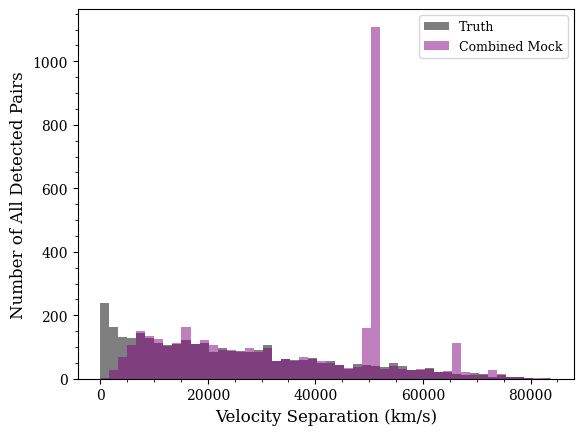

In [26]:
# plot as a function of velocity separation
dla_cat_all_no_bal = make_lambda_z_BAL_qso_cuts(dla_cat_init, lambda_min, lambda_max, z_min, z_max, bal_remove=True, cat_bal=bal_cat)
combined_cat_all_no_bal = make_lambda_z_BAL_qso_cuts(combined_cat_init, lambda_min, lambda_max, z_min, z_max, bal_remove=True, cat_bal=bal_cat, zdla='Z_DLA')

# Alex note: Ask what this is?
tp_combined_all_no_bal = ~np.isnan(combined_cat_all_no_bal['NHI_TRUE'])

def get_velocity_separations(cat, min_nhi, nhi_key, min_snr, snr_key, min_goodness=0.0, goodness_key='', zdla_key='Z_DLA', truth=False):
    vseps = []
    # apply cuts:
    # NHI
    minimum_mask = min_nhi < cat[nhi_key]

    # Goodness
    if(truth==False):
        minimum_mask &= min_goodness < cat[goodness_key]

    # SNR
    minimum_mask &= min_snr < cat[snr_key]
    cat = cat[minimum_mask]
    
    unique_ids, counts = np.unique(cat['TARGETID'], return_counts=True)
    multi_dla_ids = unique_ids[counts > 1]


    for tid in multi_dla_ids:
        idx = np.where(cat['TARGETID'] == tid)[0]
        zs = cat[zdla_key][idx]
        v_diffs_los = []
        # if(len(idx) > 2):
        #     print(len(idx))
        for i in range(len(idx)):
            others = np.delete(zs, i)
            z_me = zs[i]
            
            v_diffs = SPEED_OF_LIGHT * np.abs(z_me - others) / (1 + (z_me + others) / 2)
            # if(len(idx) > 2):
            #     print(v_diffs)
            v_diffs_los.extend(v_diffs)

        v_diffs_los = list(np.unique(v_diffs_los))
        # if(len(idx) > 2):
        #     print(v_diffs_los)
            
        vseps.extend(v_diffs_los)
            # vseps[idx[i]] = np.min(v_diffs)
            
    return vseps

nhi_min = 20.3
snr_min = 2.0


vsep_truth = get_velocity_separations(dla_cat_all_no_bal, nhi_min, 'NHI', snr_min, 'S2N_RED', truth=True)
vsep_combined = get_velocity_separations(combined_cat_all_no_bal, nhi_min, 'NHI', snr_min, 'S2N_RED', gp_conf, 'P_DLA_GP')

print(len(vsep_truth))

vsep_min = min(np.nanmin(vsep_truth), np.nanmin(vsep_combined))
vsep_max = max(np.nanmax(vsep_truth), np.nanmin(vsep_combined))

Nz = 50
vsep_bins = np.linspace(vsep_min, vsep_max, Nz + 1)

plt.hist(vsep_truth, bins = vsep_bins, alpha=0.5, color='black', label='Truth')
plt.hist(vsep_combined, bins = vsep_bins, alpha=0.5, color='purple', label='Combined Mock')

plt.xlabel('Velocity Separation (km/s)')
plt.ylabel('Number of All Detected Pairs')
plt.legend()
plt.show()


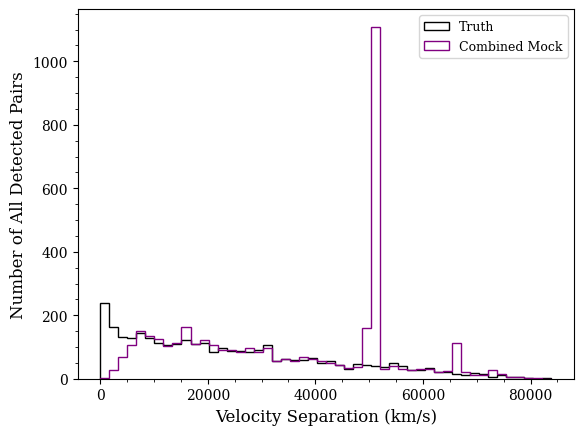

In [27]:
# plt.hist(vsep_truth, bins = vsep_bins, alpha=0.5, color='black', histtype='step', label='Truth')

plt.hist(vsep_truth, bins = vsep_bins, alpha=1.0, color='black', histtype='step', label='Truth')
plt.hist(vsep_combined, bins = vsep_bins, alpha=1.0, color='purple', histtype='step', label='Combined Mock')
plt.xlabel('Velocity Separation (km/s)')
plt.ylabel('Number of All Detected Pairs')
plt.legend()
plt.show()

In [28]:
# now compute completeness 
def compute_completeness_min_max_vsep(vsep_det, vsep_truth, min_vsep, max_vsep, mock_cat):
    
    minimum_mask = min_vsep < vsep_det
    minimum_mask &= vsep_det < max_vsep
                
    mock_mask = min_vsep < vsep_truth
    mock_mask &= vsep_truth < max_vsep
    

     # Compute completeness for the current minimum cut
    if(np.sum(mock_mask) == 0):
        return np.nan
        
    completeness_min = np.sum(minimum_mask) / np.sum(mock_mask)

    return completeness_min


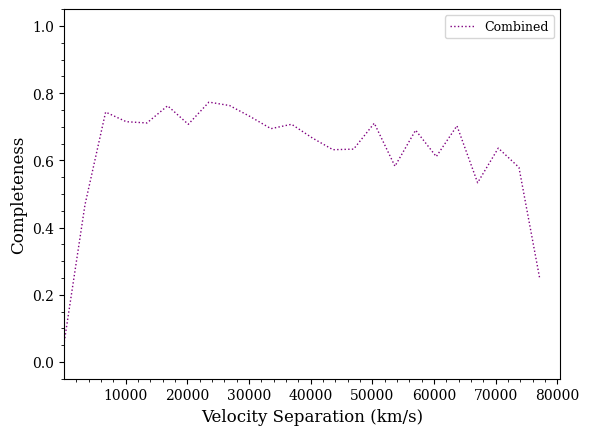

In [30]:


'''
Compute the completeness for each vsep bin:
- Because each vsep value is over two different DLAs,
I cannot apply the masks to the vsep array, as previously done to the 
completeness plots over S/N or Z_DLA. Thus, I wll apply the masks to
the catalogs FIRST, then compute the vsep arrays, then compute completeness
(This is similar to before, except now my completeness function will not deal with masks other
than the vsep bin mask)
'''
# rest arrays:
dla_cat_all_no_bal = make_lambda_z_BAL_qso_cuts(dla_cat_init, lambda_min, lambda_max, z_min, z_max, bal_remove=True, cat_bal=bal_cat)
combined_cat_all_no_bal = make_lambda_z_BAL_qso_cuts(combined_cat_init, lambda_min, lambda_max, z_min, z_max, bal_remove=True, cat_bal=bal_cat, zdla='Z_DLA')

tp_combined_all_no_bal = ~np.isnan(combined_cat_all_no_bal['NHI_TRUE'])


snr_min = 2.
nhi_min_both = 20.3
# nhi_min_both = 20.1


# Make cuts:
# NHI masks
dla_mask = dla_cat_all_no_bal['NHI'] > 20.3
combined_mask = combined_cat_all_no_bal['NHI'] > 20.3

# goodness masks 
combined_mask &= combined_cat_all_no_bal['P_DLA_GP'] > gp_conf

# SNR cut:
combined_mask &= combined_cat_all_no_bal['S2N_RED'] > 2.0
# And apply good mask for gp:

# And TRUE positives masks:
combined_mask &= tp_combined_all_no_bal

# Apply masks (make cuts):


dla_cat_all_no_bal = dla_cat_all_no_bal[dla_mask]
combined_cat_all_no_bal = combined_cat_all_no_bal[combined_mask]


vsep_truth = get_velocity_separations(dla_cat_all_no_bal, nhi_min, 'NHI', snr_min, 'S2N_RED', truth=True)
vsep_combined = get_velocity_separations(combined_cat_all_no_bal, nhi_min, 'NHI', snr_min, 'S2N_RED', gp_conf, 'P_DLA_GP')

Nz = 25
vsep_min = min(np.nanmin(vsep_truth), np.nanmin(vsep_combined))
vsep_max = max(np.nanmax(vsep_truth), np.nanmax(vsep_combined))
vsep_bins = np.linspace(vsep_min, vsep_max, Nz + 1)

c_vsep_bins_combined_all_no_bal = np.empty([len(vsep_bins)-1])

for v_idx, vsep in enumerate(vsep_bins[:-1]):

    c_vsep_bins_combined_all_no_bal[v_idx] = compute_completeness_min_max_vsep( 
        vsep_combined, vsep_truth, vsep, vsep_bins[v_idx + 1], dla_cat_all_no_bal
    )


x_values = vsep_bins[:-1]
plt.plot(x_values, c_vsep_bins_combined_all_no_bal, linestyle=':', label=f'Combined', c='purple')

plt.xlim([x_values[0], x_values[-1]])
plt.ylim([-.05, 1.05])
plt.ylabel('Completeness')

# purity_axis.set_xlabel('log$_{10}$(S/N)')
# completeness_axis.set_xlabel('log$_{10}$(S/N)')
plt.xlabel('Velocity Separation (km/s)')
plt.legend()
plt.show()

In [65]:



N_exp_arr = [] # from integral
N_sim_arr = [] # from poisson of N_exp
N_dla_pair_arr = [] # from data
deltav_arr = []
deltav_sim_arr = []
# c_vsep_bins = []
Nmin = 20.3
Nmax = 23 # from example in pyigm


TARGETID = gpp['TARGETID']
TARGETID_masked = TARGETID[quality_mask]
Z_QSO = gpp['Z_QSO']
Z_QSO_masked = Z_QSO[quality_mask]
Z_DLA = gpp['Z_DLA']
Z_DLA_masked = Z_DLA[quality_mask]
unique_ID, dla_per_qso = np.unique(TARGETID_masked, return_counts=True)
print(len(unique_ID))

''' PROCESS:
- z_min and z_max do not relate to specific pair separations
- for each line of sight, 
- define z_min and zmax
- compute deltaX
- compute l(X)
- compute n_exp
- poisson sample to get n_sim 
- random sample x vals --> convert to z vals --> convert to dv
'''


# iterates over each unique TargetID, i.e each LoS i.e each QSO
for i in range(len(unique_ID)):
    if(i % 1000 == 0):
        print("Iteration " + str(i))

    z_rand = []

    index_los = np.where(TARGETID_masked == unique_ID[i])[0] # bc unique_ID has different indices
    z_dla = Z_DLA_masked[index_los] # size of this depends on how many DLAs are in LoS

    if(len(z_dla) > 1): # if there's a pair of DLAs

        # print("computing combinations")
        for z1, z2 in combinations(z_dla, 2): # all combinations
            deltav = np.abs(delta_v(z1, z2))
            deltav_arr.append(deltav)
        

        
    # Now compute expected/random
    z_max = Z_QSO_masked[index_los][0] - (3000/c)
    z_min = max([(912/1216)*(1 + Z_QSO_masked[index_los][0]) - 1 + (3000/c), (3600/1216)- 1]) 

    if(z_max > 3.0): # TEMP FIX FOR ERROR, ask
        # print("invalid z_max")
        continue
        
    Nz = 25
    z_grid = np.linspace(z_min, z_max, Nz+1)
    z_bins_mid = 0.5 * (z_grid[1:] + z_grid[:-1])
    
    lX = fN_default.calculate_lox(z_bins_mid, Nmin, Nmax)

    # incorporate completeness:
    '''
    From Ming-Feng: random absorbers at rate ∝ [unclustered Poisson expectation  dn/dX] × C(zDLA | S/N > 1 or 2)
    '''

    c_zdla_bins = np.zeros(Nz)

    for zdla_idx in range(Nz):
        
        z_start = z_grid[zdla_idx]
        z_end = z_grid[zdla_idx + 1]
        
        c_zdla_bins[zdla_idx] = compute_completeness_min_max_zdla(
            combined_cat_all_no_bal, tp_combined_all_no_bal, z_start, z_end, 
            nhi_min_both, nhi_min_both, gp_conf, snr_min, dla_cat_all_no_bal,
            nhi_key='NHI', goodness_key='P_DLA_GP'
        )

    c_zdla_bins = np.nan_to_num(c_zdla_bins, nan=0.0)
    c_zdla_bins[c_zdla_bins > 1.0] = 0.0
    c_zdla_bins[~np.isfinite(c_zdla_bins)] = 0.0
        
    lX_complete = lX * c_zdla_bins
    
    X_grid = cosmo.absorption_distance(z_grid)
    dX = np.abs(np.diff(X_grid))
    

    # Integrate
    # N_expected = trapezoid(lX_complete, X_grid)
    N_expected = np.sum(lX_complete * dX)
    
    N_sampled = np.random.poisson(N_expected)
    if N_sampled > 1: # if simulated at least one pair, simulate the distance

        lX_complete /= lX_complete.sum() # normalize probabilities

        # weighted sampling 
        z_rand = np.random.choice(z_bins_mid, size=N_sampled, replace=True, p=lX_complete)
        
        #compute all unique pairs
        for z1, z2 in combinations(z_rand, 2):
            dv_sim = np.abs(delta_v(z1, z2))
            deltav_sim_arr.append(dv_sim)

    N_exp_arr.append(N_expected)
    N_sim_arr.append(N_sampled)

    
print(type(N_sim_arr))
print(np.shape(N_sim_arr))

42296
Iteration 0


/var/folders/8q/2w_x2pln27g0dnf_c4vg80nm0000gn/T/ipykernel_65364/4251564591.py:144: RuntimeWarning: invalid value encountered in scalar divide
  completeness_min = np.sum(det_TP[minimum_mask]) / np.sum(mock_mask)


Iteration 1000
Iteration 2000
Iteration 3000
Iteration 4000
Iteration 5000
Iteration 6000
Iteration 7000
Iteration 8000
Iteration 9000
Iteration 10000
Iteration 11000
Iteration 12000
Iteration 13000
Iteration 14000
Iteration 15000
Iteration 16000
Iteration 17000
Iteration 18000
Iteration 19000
Iteration 20000
Iteration 21000
Iteration 22000
Iteration 23000
Iteration 24000
Iteration 25000
Iteration 26000
Iteration 27000
Iteration 28000
Iteration 29000
Iteration 30000
Iteration 31000
Iteration 32000
Iteration 33000
Iteration 34000
Iteration 35000
Iteration 36000
Iteration 37000
Iteration 38000
Iteration 39000
Iteration 40000
Iteration 41000
Iteration 42000
<class 'list'>
(24970,)


2
(4509,)
(69,)


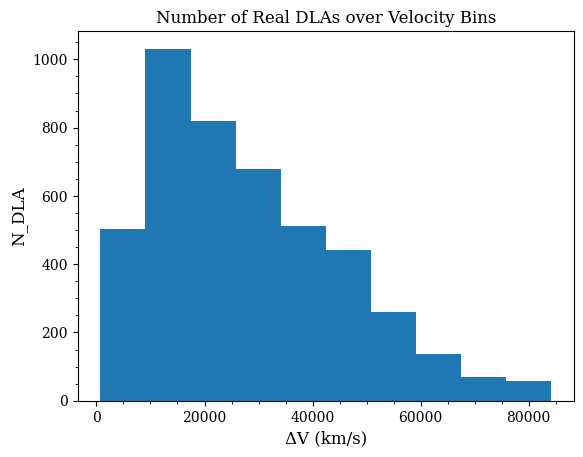

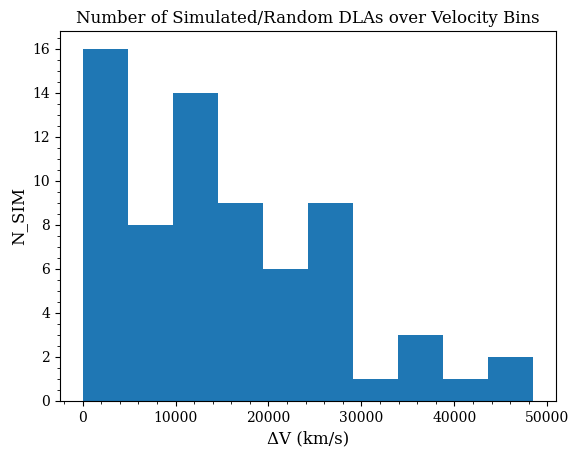

In [66]:

# plot data N_DLA over velocity bin:
print(np.max(N_sim_arr))
print(np.shape(deltav_arr))
print(np.shape(deltav_sim_arr))

plt.hist(deltav_arr)
plt.title("Number of Real DLAs over Velocity Bins")
plt.xlabel("ΔV (km/s)")
plt.ylabel("N_DLA")
plt.show()
plt.hist(deltav_sim_arr)
plt.title("Number of Simulated/Random DLAs over Velocity Bins")
plt.xlabel("ΔV (km/s)")
plt.ylabel("N_SIM")
plt.show()


84176.38410424194


/var/folders/8q/2w_x2pln27g0dnf_c4vg80nm0000gn/T/ipykernel_65364/4090942176.py:31: RuntimeWarning: divide by zero encountered in divide
  DD_upweighted = DD_counts / c_vsep_bins
/var/folders/8q/2w_x2pln27g0dnf_c4vg80nm0000gn/T/ipykernel_65364/525069111.py:9: RuntimeWarning: divide by zero encountered in divide
  return n_obs/n_exp - 1


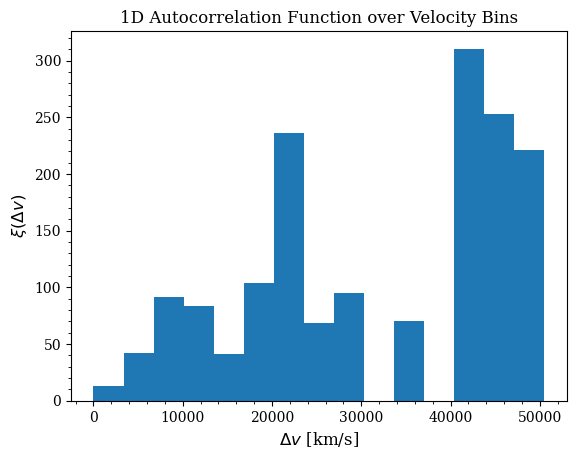

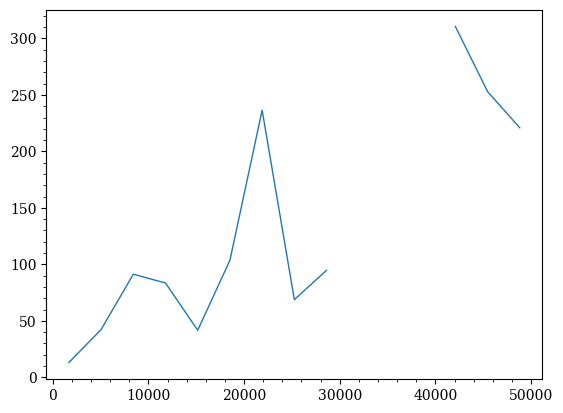

In [74]:
# compute clustering:


# # compute clustering:
dv_max = max(max(deltav_arr), max(deltav_sim_arr))
print(dv_max)

Ndv = 25
bins = np.linspace(0, dv_max, Ndv+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])


DD_counts, _ = np.histogram(deltav_arr, bins=bins)
RR_counts, _ = np.histogram(deltav_sim_arr, bins=bins)


# compute completeness in vsep
c_vsep_bins = np.zeros(Ndv)

for v_idx, vsep in enumerate(bin_centers[:-1]):

    c_vsep_bins[v_idx] = compute_completeness_min_max_vsep( 
        vsep_combined, vsep_truth, vsep, bin_centers[v_idx + 1], dla_cat_all_no_bal
    )


c_vsep_bins = np.nan_to_num(c_vsep_bins, nan=0.0)
c_vsep_bins[c_vsep_bins > 1.0] = 0.0
c_vsep_bins[~np.isfinite(c_vsep_bins)] = 0.0

DD_upweighted = DD_counts / c_vsep_bins
xi = cluster_1d(DD_upweighted, RR_counts)

# plt.step(bin_centers, xi, where='mid')
plt.bar(bin_centers, xi, width=bin_centers[1]-bin_centers[0])
plt.xlabel(r'$\Delta v$ [km/s]')
plt.ylabel(r'$\xi(\Delta v)$')
plt.title("1D Autocorrelation Function over Velocity Bins")
plt.show()

# plt.bar(bin_centers, xi, width=bin_centers[1]-bin_centers[0])
# plt.xlabel(r'$\Delta v$ [km/s]')
# plt.ylabel(r'$\xi(\Delta v)$')
# plt.show()
# plt.plot(bin_centers, xi)

plt.plot(bin_centers, xi)
plt.show()
